In [14]:
from utils.config import RAW_CONFIG, RELEVANT_CONFIG, PROJECT_ROOT
from netCDF4 import Dataset as NETCDF4Dataset
from utils.datasettemporal import TemporalDataset
import os
from pathlib import Path

In [15]:
root = Path(PROJECT_ROOT)
filepath = root / "data/daily_small/small_daily_sample_1993-1993.nc"
dataset = TemporalDataset(filepath = filepath, normalize = True)

In [16]:
feature_map = dataset.feature_map
annotation_map = dataset.annotations_map
feature_map.shape, annotation_map.shape

((30, 6, 145, 157), (30, 1, 145, 157))

In [17]:
from sklearn.preprocessing import StandardScaler
import numpy as np

combined_map = np.concatenate((feature_map, annotation_map), axis=1)
combined_map.shape


(30, 7, 145, 157)

In [18]:
dataset.all_variables.keys()



dict_keys(['bottomT', 'so', 'thetao', 'uo', 'vo', 'zos', 'mlotst'])

In [19]:
import xarray as xr
ds = xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 38MB
Dimensions:    (depth: 1, latitude: 145, longitude: 157, time: 30)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 580B 49.0 49.08 49.17 ... 60.83 60.92 61.0
  * longitude  (longitude) float32 628B -143.0 -142.9 -142.8 ... -130.1 -130.0
  * time       (time) datetime64[ns] 240B 1993-01-01 1993-01-02 ... 1993-01-30
Data variables:
    bottomT    (time, latitude, longitude) float64 5MB ...
    so         (time, depth, latitude, longitude) float64 5MB ...
    thetao     (time, depth, latitude, longitude) float64 5MB ...
    uo         (time, depth, latitude, longitude) float64 5MB ...
    vo         (time, depth, latitude, longitude) float64 5MB ...
    zos        (time, latitude, longitude) float64 5MB ...
    mlotst     (time, latitude, longitude) float64 5MB ...
Attributes:
    comment:                   CMEMS product
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    institution:               MERCATOR OCEAN
    references:                http://www.mercator-ocean.fr
    Conventions:               CF-1.4
    copernicusmarine_version:  2.1.0

In [20]:
type(ds.data_vars)

xarray.core.dataset_variables.DataVariables

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


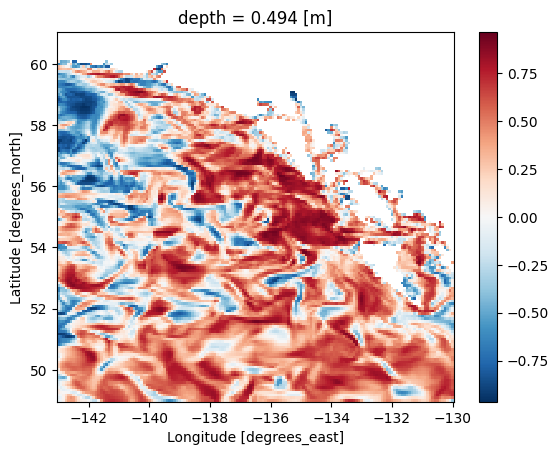

In [21]:
cors = xr.corr(ds.mlotst, ds.thetao, dim='time')
cors.plot()

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

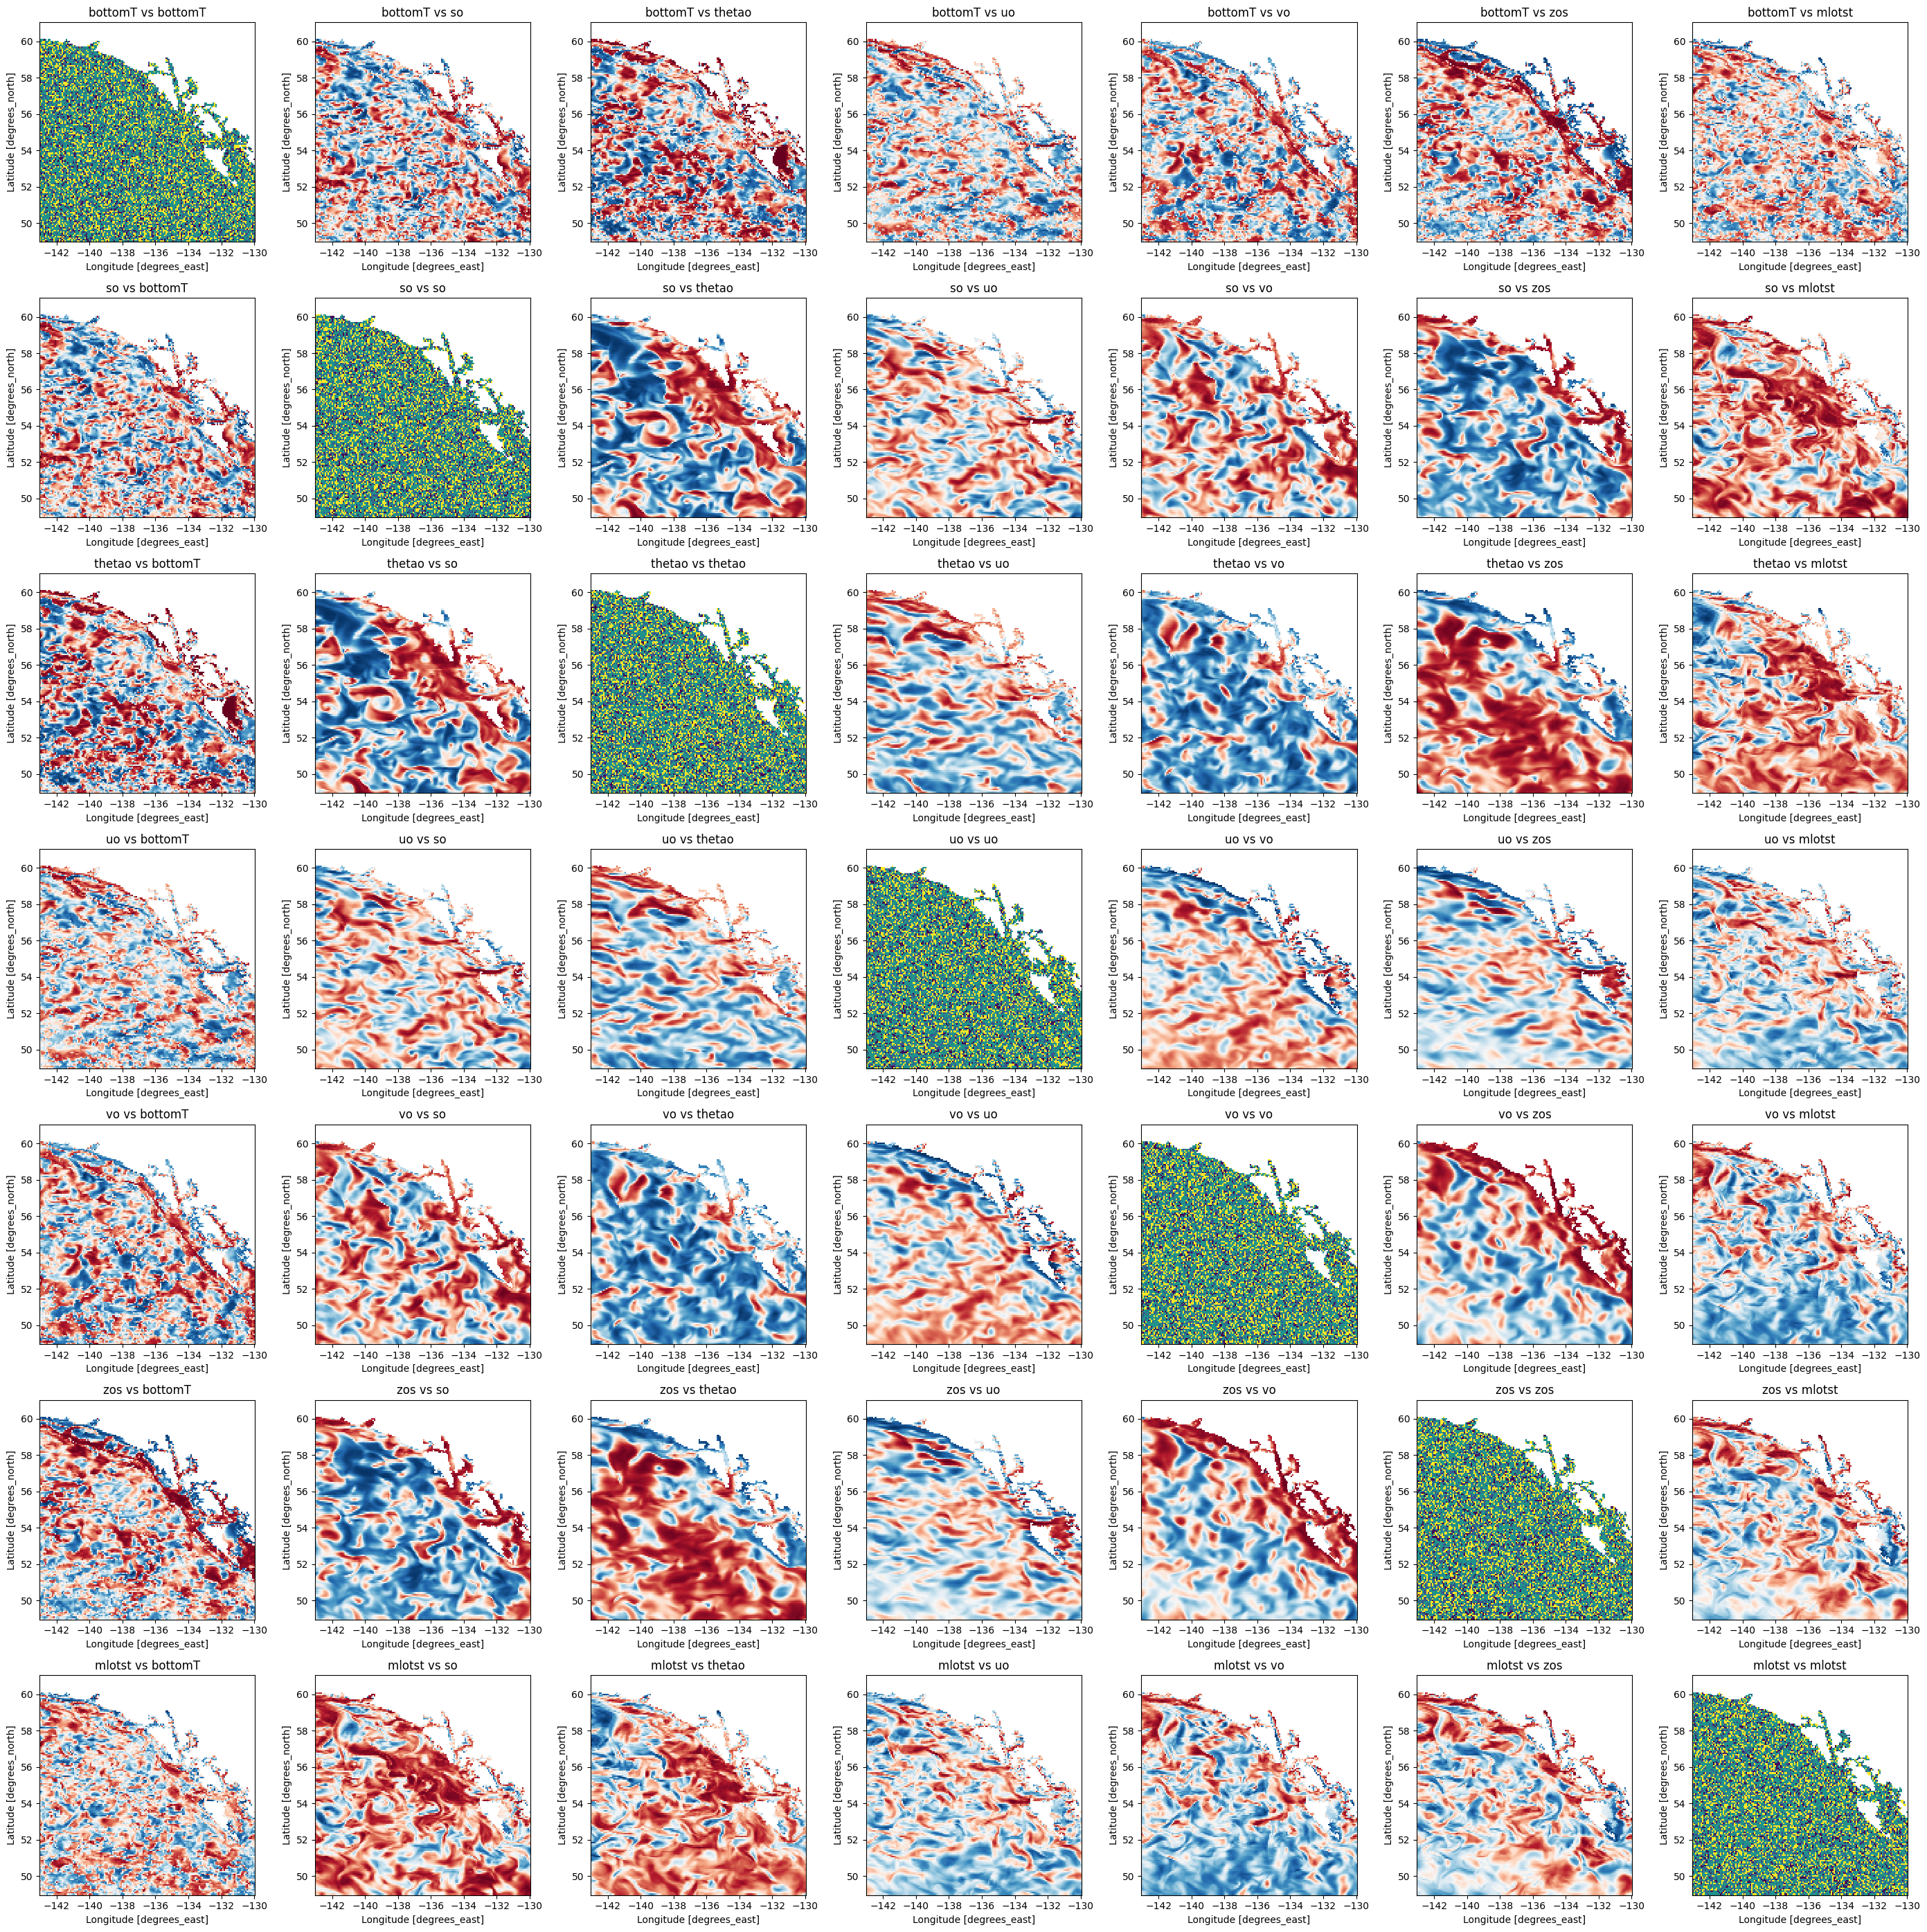

In [22]:
import matplotlib.pyplot as plt

variables = list(ds.data_vars)
n = len(variables)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        # Only compute correlation if dimensions overlap
        try:
            cors = xr.corr(ds[var1], ds[var2], dim='time')
            # If depth exists, select the first depth for plotting
            if 'depth' in cors.dims:
                cors = cors.isel(depth=0)
            ax = axes[i, j]
            cors.plot(ax=ax, add_colorbar=False)
            ax.set_title(f"{var1} vs {var2}")
        except Exception as e:
            axes[i, j].set_visible(False)
plt.tight_layout()
plt.show()


In [23]:
ds['mlotst']

<xarray.DataArray 'mlotst' (time: 30, latitude: 145, longitude: 157)> Size: 5MB
[682950 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 580B 49.0 49.08 49.17 ... 60.83 60.92 61.0
  * longitude  (longitude) float32 628B -143.0 -142.9 -142.8 ... -130.1 -130.0
  * time       (time) datetime64[ns] 240B 1993-01-01 1993-01-02 ... 1993-01-30
Attributes:
    standard_name:  ocean_mixed_layer_thickness_defined_by_sigma_theta
    units:          m
    valid_max:      4525
    valid_min:      1
    unit_long:      Meters
    long_name:      Density ocean mixed layer thickness

In [24]:
coarse_ds = ds.coarsen(latitude=3, longitude=3, boundary='trim').mean()


/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

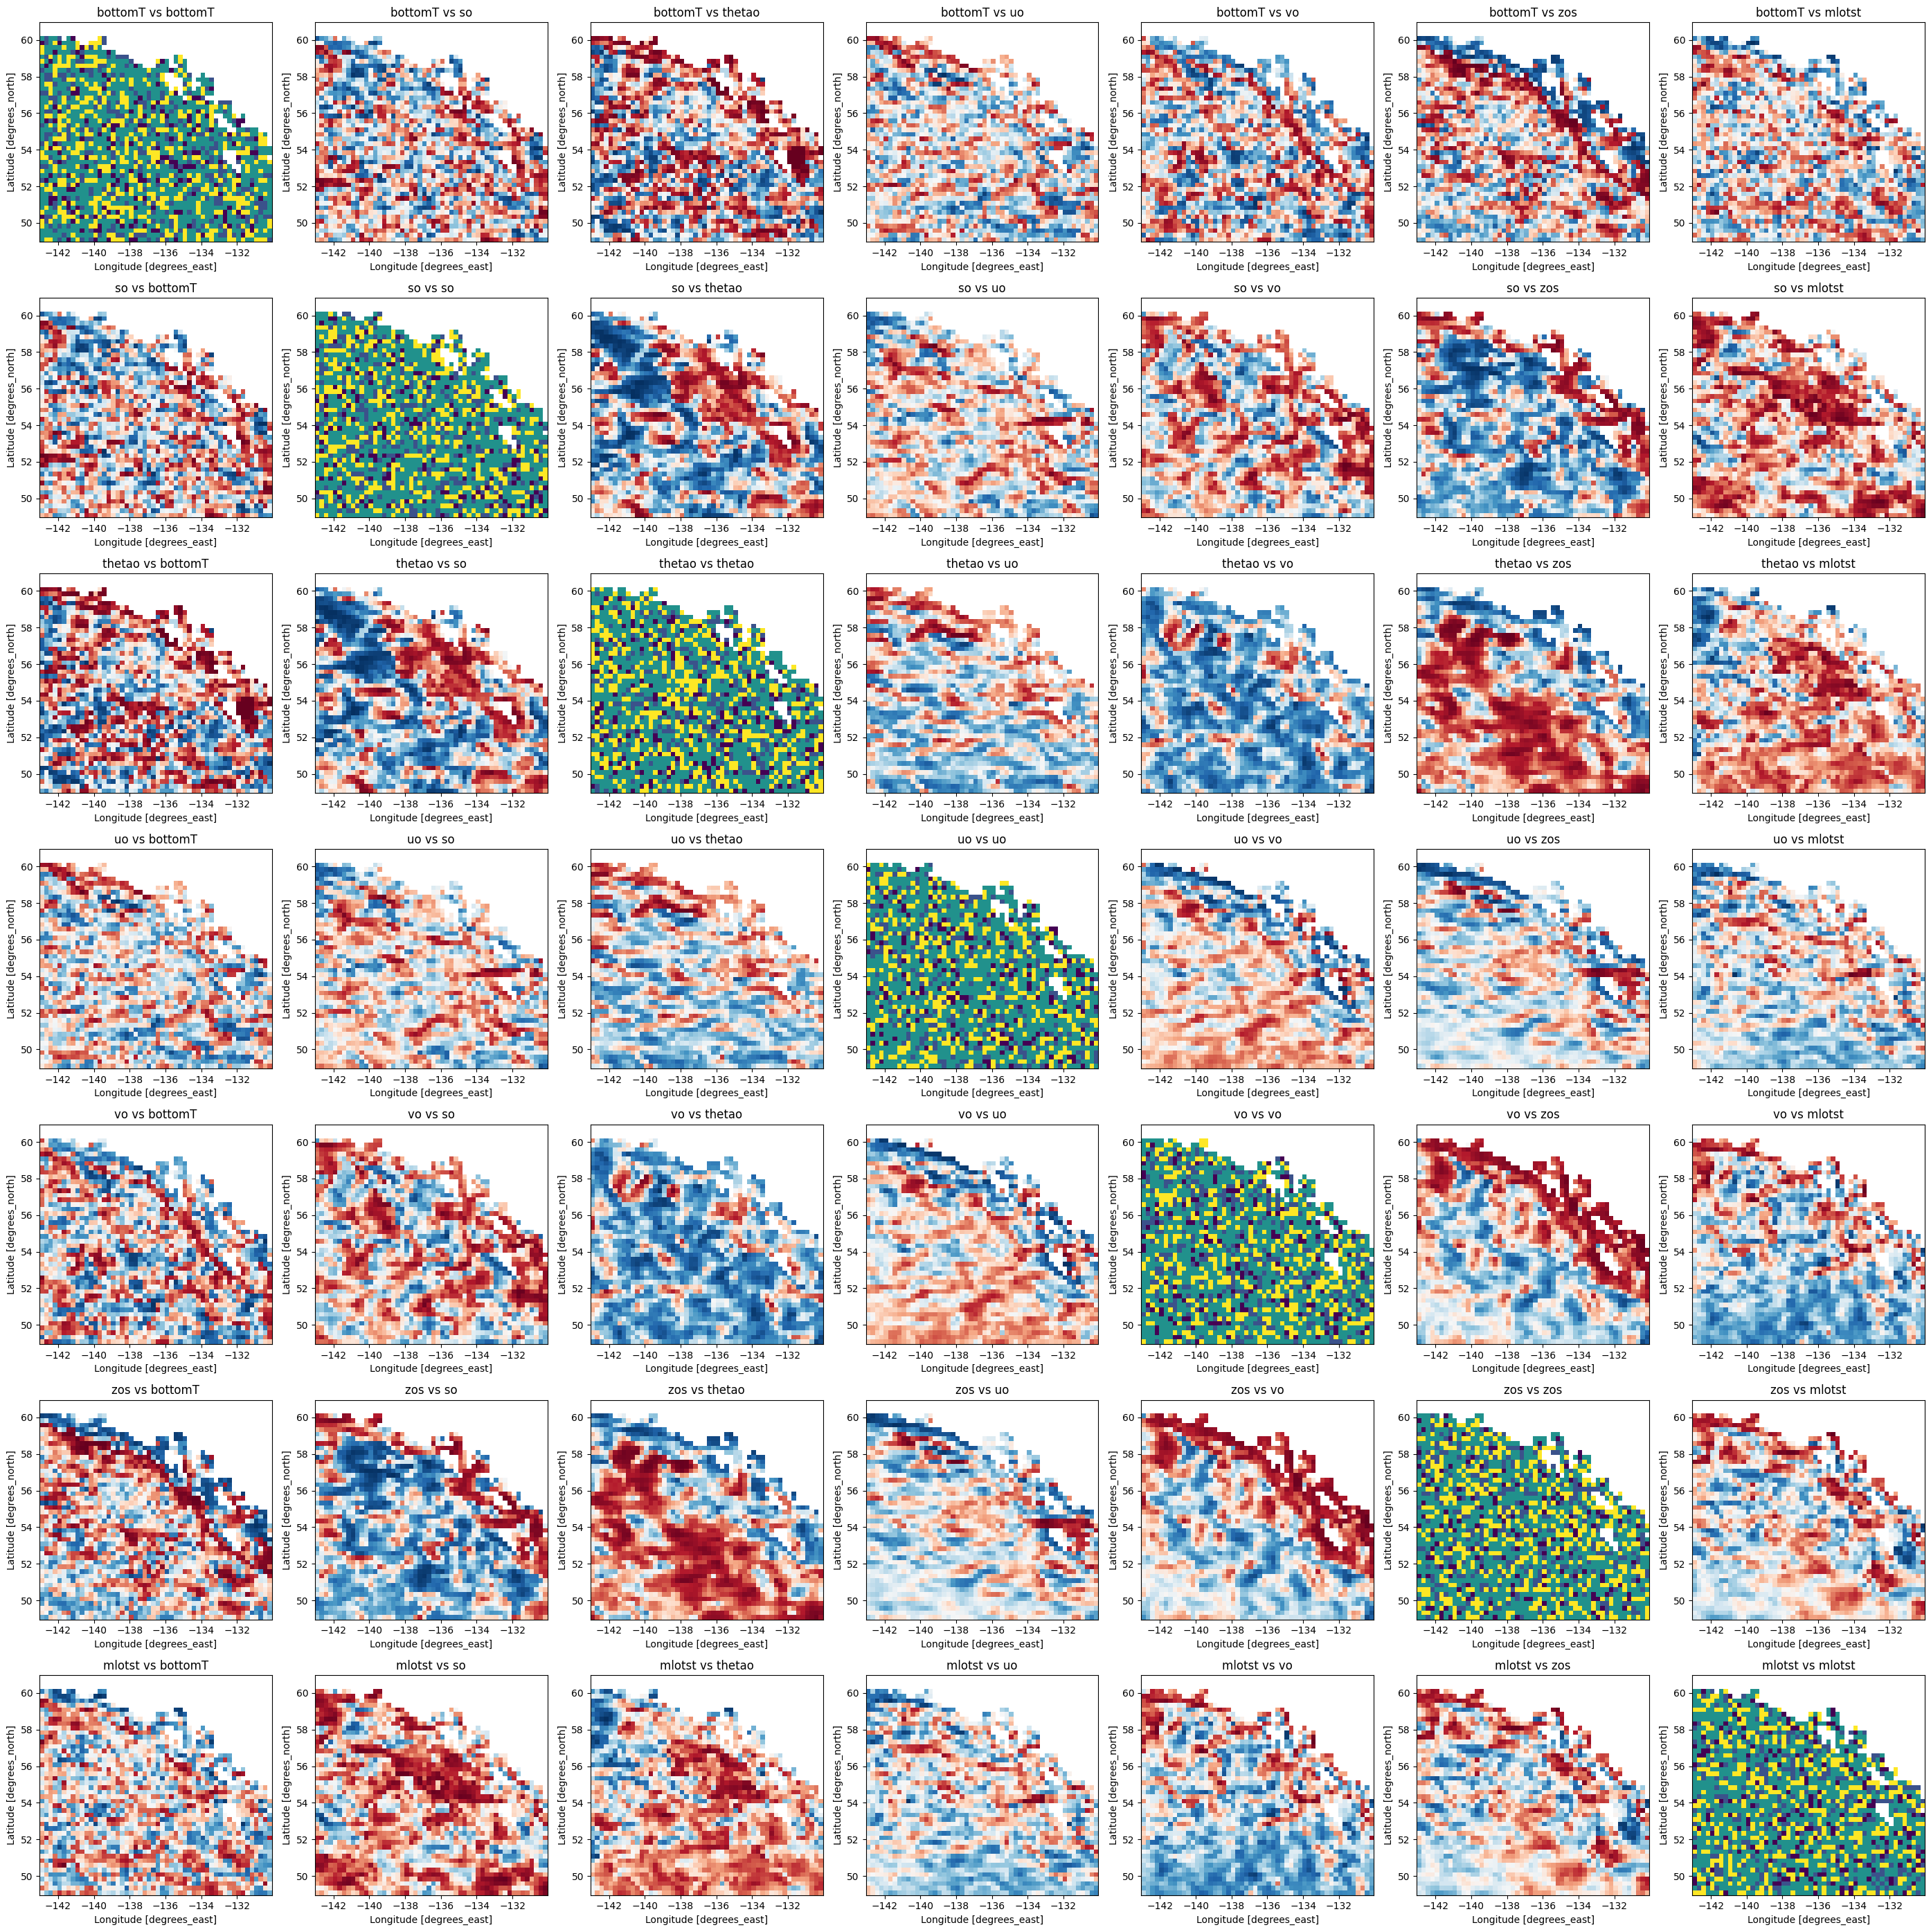

In [25]:
import matplotlib.pyplot as plt



variables = list(coarse_ds.data_vars)
n = len(variables)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        # Only compute correlation if dimensions overlap
        try:
            cors = xr.corr(coarse_ds[var1], coarse_ds[var2], dim='time')
            # If depth exists, select the first depth for plotting
            if 'depth' in cors.dims:
                cors = cors.isel(depth=0)
            ax = axes[i, j]
            cors.plot(ax=ax, add_colorbar=False)
            ax.set_title(f"{var1} vs {var2}")
        except Exception as e:
            axes[i, j].set_visible(False)
plt.tight_layout()
plt.show()


/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

Text(0.5, 1.0, 'Original mlotst vs thetao')

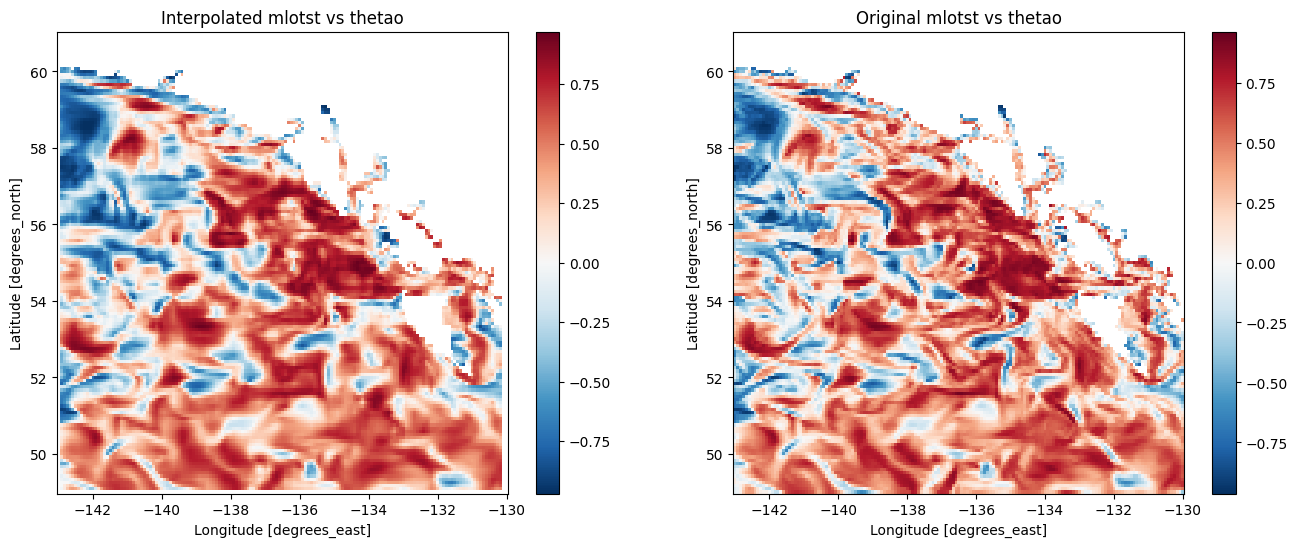

In [47]:
# Downsample (lower scale)
mlotst_coarse = ds['mlotst'].coarsen(latitude=3, longitude=3, boundary='trim').mean()

# Interpolate back to original grid
mlotst_interp = mlotst_coarse.interp(
    latitude=ds['mlotst'].latitude,
    longitude=ds['mlotst'].longitude,
    method='linear'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xr.corr(mlotst_interp, ds['thetao'], dim='time').plot(ax=axes[0])
axes[0].set_title('Interpolated mlotst vs thetao')
xr.corr(ds['mlotst'], ds['thetao'], dim='time').plot(ax=axes[1])
axes[1].set_title('Original mlotst vs thetao')

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

Text(0.5, 1.0, 'Original thetao vs mlotst')

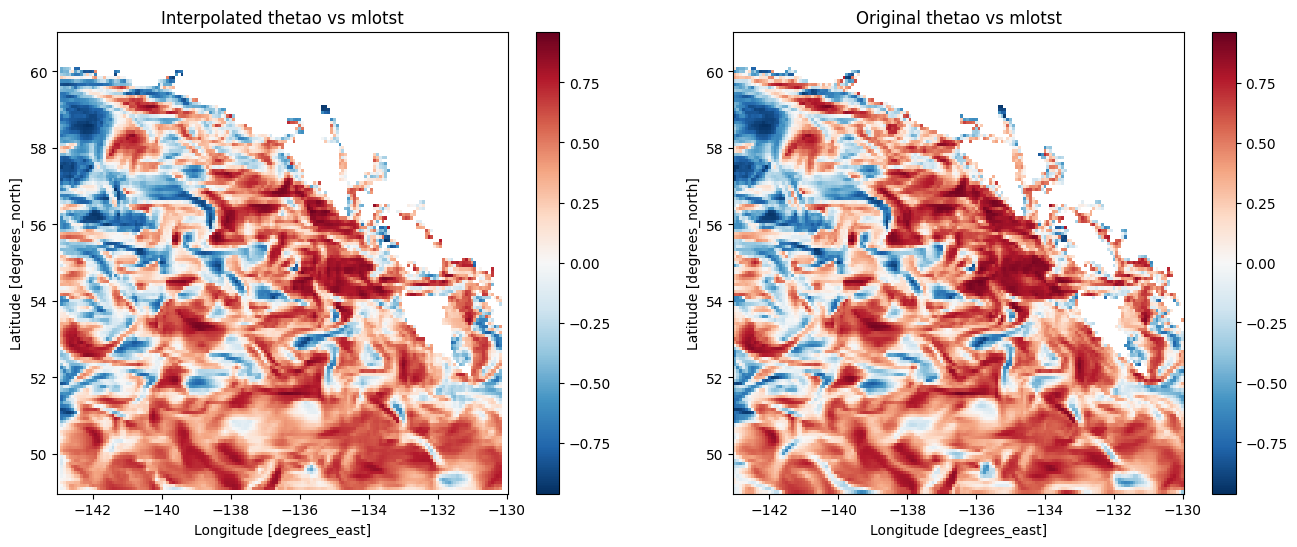

In [52]:
# Downsample (lower scale)
thetao_coarse = ds['thetao'].coarsen(latitude=3, longitude=3, boundary='trim').mean()

# Interpolate back to original grid
thetao_interp = thetao_coarse.interp(
    latitude=ds['thetao'].latitude,
    longitude=ds['thetao'].longitude,
    method='linear'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xr.corr(thetao_interp, ds['mlotst'], dim='time').plot(ax=axes[0])
axes[0].set_title('Interpolated thetao vs mlotst')
xr.corr(ds['thetao'], ds['mlotst'], dim='time').plot(ax=axes[1])
axes[1].set_title('Original thetao vs mlotst')

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar

Text(0.5, 1.0, 'Original thetao vs mlotst')

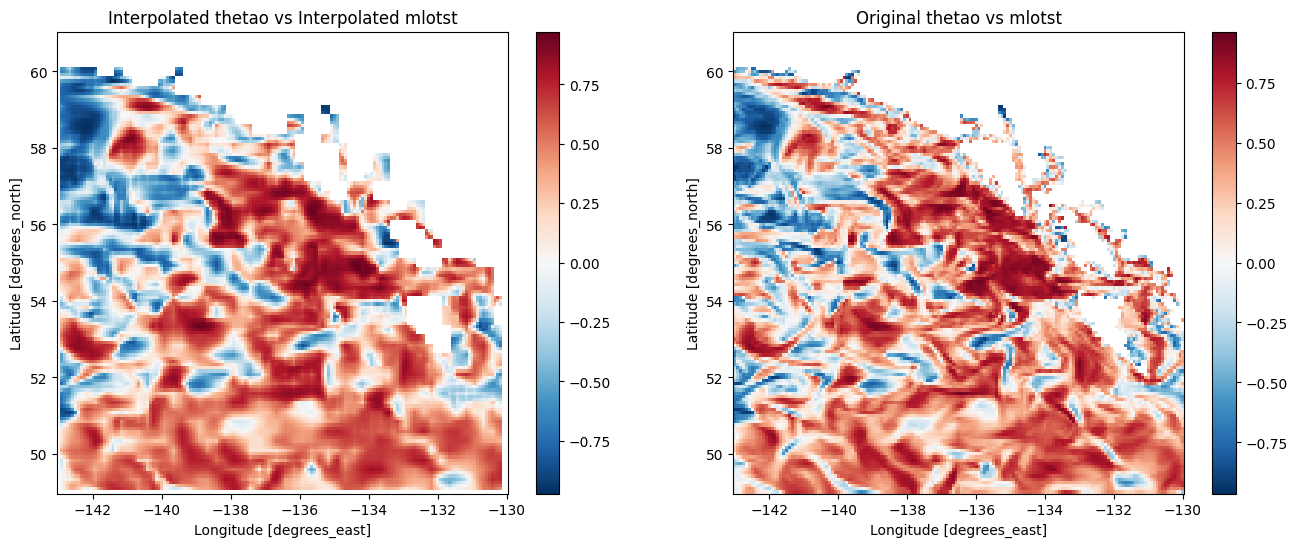

In [53]:
# Downsample (lower scale)
thetao_coarse = ds['thetao'].coarsen(latitude=3, longitude=3, boundary='trim').mean()
mlotst_coarse = ds['mlotst'].coarsen(latitude=3, longitude=3, boundary='trim').mean()

# Interpolate back to original grid
thetao_interp = thetao_coarse.interp(
    latitude=ds['thetao'].latitude,
    longitude=ds['thetao'].longitude,
    method='linear'
)
mlotst_interp = mlotst_coarse.interp(
    latitude=ds['mlotst'].latitude,
    longitude=ds['mlotst'].longitude,
    method='linear'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xr.corr(thetao_interp, mlotst_interp, dim='time').plot(ax=axes[0])
axes[0].set_title('Interpolated thetao vs Interpolated mlotst')
xr.corr(ds['thetao'], ds['mlotst'], dim='time').plot(ax=axes[1])
axes[1].set_title('Original thetao vs mlotst')

In [45]:
from eofs.xarray import Eof

ds2 = ds[['thetao', 'mlotst']].to_array('feature')
ds2 = ds2.transpose('time', 'feature', 'depth', 'latitude', 'longitude')
solver = Eof(ds2)
eofs = solver.eofs(neofs=3)
pcs = solver.pcs(npcs=3, pcscaling=1)
frac = solver.varianceFraction(neigs=3)*100

/mnt/c/Users/samue/.cache/pypoetry/virtualenvs/oceanpropinfsatimg-hx3efDLg-py3.12/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


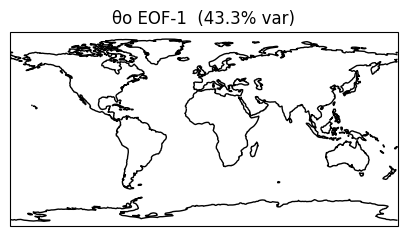

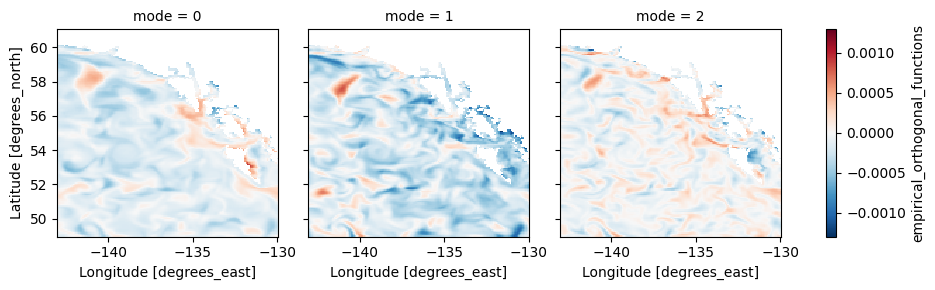

In [51]:
import cartopy.crs as ccrs               # nicer coastlines; drop if not installed

fig, ax = plt.subplots(
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    figsize=(5,4)
)

# (eofs.sel(feature='thetao').isel(mode=0)      # θo, EOF-1
#       .plot(ax=ax, transform=ccrs.PlateCarree(),  # put data on the map
#              cmap='RdBu_r',                    # diverging colours
#              cbar_kwargs={'label':'normalised loading'}))

eofs.sel(feature='thetao').isel(mode=slice(0,3)).plot(
    col='mode', col_wrap=3, cmap='RdBu_r', figsize=(10,3)
)

ax.coastlines()
ax.set_title(f"θo EOF-1  ({frac[0].item():.1f}% var)")
plt.show()

In [128]:
# thetao = ds[['thetao', 'so']]
thetao = ds['thetao']
mlotst = ds['mlotst']

In [133]:
# X = thetao.isel(time=0)
X = thetao
X = X.stack(spatial=['latitude', 'longitude'])
X = X.dropna('spatial')
X = X.squeeze()

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)

In [135]:
mld_mean = mlotst.mean(dim=("latitude", "longitude")).values
# Use MLD from the first day only
# mld_mean = mlotst.isel(time=0).mean(dim=("latitude", "longitude")).values

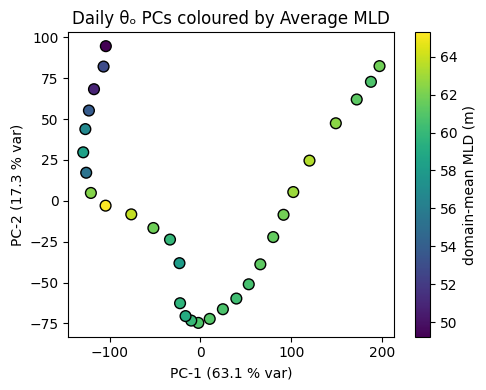

In [136]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,4))
sc = ax.scatter(
    scores[:,0], scores[:,1],
    c=mld_mean, cmap="viridis",
    edgecolor="k", s=60
)
ax.set_xlabel("PC-1 ({:.1f} % var)".format(pca.explained_variance_ratio_[0]*100))
ax.set_ylabel("PC-2 ({:.1f} % var)".format(pca.explained_variance_ratio_[1]*100))
cb = plt.colorbar(sc, ax=ax)
cb.set_label("domain-mean MLD (m)")
ax.set_title("Daily θₒ PCs coloured by Average MLD")
plt.tight_layout()
plt.show()

In [141]:
ds_nona = ds.stack(spatial=['latitude', 'longitude'])
ds_nona = ds_nona.dropna('spatial')
ds_nona = ds_nona.squeeze()
ds_nona = ds_nona.transpose('spatial', 'time')
ds_nona

<xarray.Dataset> Size: 28MB
Dimensions:    (time: 30, spatial: 16431)
Coordinates:
    depth      float32 4B 0.494
  * time       (time) datetime64[ns] 240B 1993-01-01 1993-01-02 ... 1993-01-30
  * spatial    (spatial) object 131kB MultiIndex
  * latitude   (spatial) float32 66kB 49.0 49.0 49.0 49.0 ... 60.08 60.08 60.08
  * longitude  (spatial) float32 66kB -143.0 -142.9 -142.8 ... -142.4 -141.4
Data variables:
    bottomT    (spatial, time) float64 4MB 1.153 1.153 1.152 ... 5.317 5.551
    so         (spatial, time) float64 4MB 32.4 32.4 32.4 ... 31.36 31.36 31.37
    thetao     (spatial, time) float64 4MB 7.12 7.136 7.124 ... 5.096 5.101
    uo         (spatial, time) float64 4MB -0.01282 0.03662 ... -0.01526
    vo         (spatial, time) float64 4MB -0.1379 -0.1141 ... 0.02747 -0.04089
    zos        (spatial, time) float64 4MB -0.01129 0.0119 ... 0.3967 0.3275
    mlotst     (spatial, time) float64 4MB 65.92 63.48 66.23 ... 104.7 81.48
Attributes:
    comment:                   CMEMS product
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    institution:               MERCATOR OCEAN
    references:                http://www.mercator-ocean.fr
    Conventions:               CF-1.4
    copernicusmarine_version:  2.1.0

In [142]:
X = ds_nona['thetao']
mlotst = ds_nona['mlotst']

In [143]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)

In [145]:
mld_mean = mlotst.mean(dim='time').values

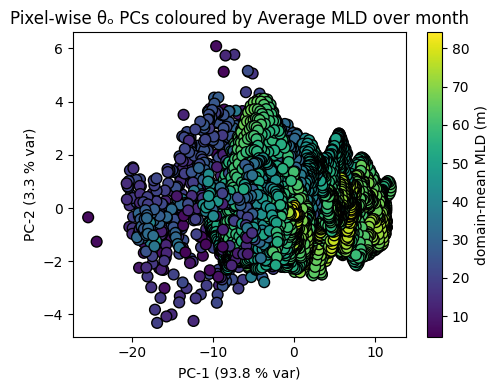

In [150]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,4))
sc = ax.scatter(
    scores[:,0], scores[:,1],
    c=mld_mean, cmap="viridis",
    edgecolor="k", s=60
)
ax.set_xlabel("PC-1 ({:.1f} % var)".format(pca.explained_variance_ratio_[0]*100))
ax.set_ylabel("PC-2 ({:.1f} % var)".format(pca.explained_variance_ratio_[1]*100))
cb = plt.colorbar(sc, ax=ax)
cb.set_label("domain-mean MLD (m)")
ax.set_title("Pixel-wise θₒ PCs coloured by Average MLD over month")
plt.tight_layout()
plt.show()

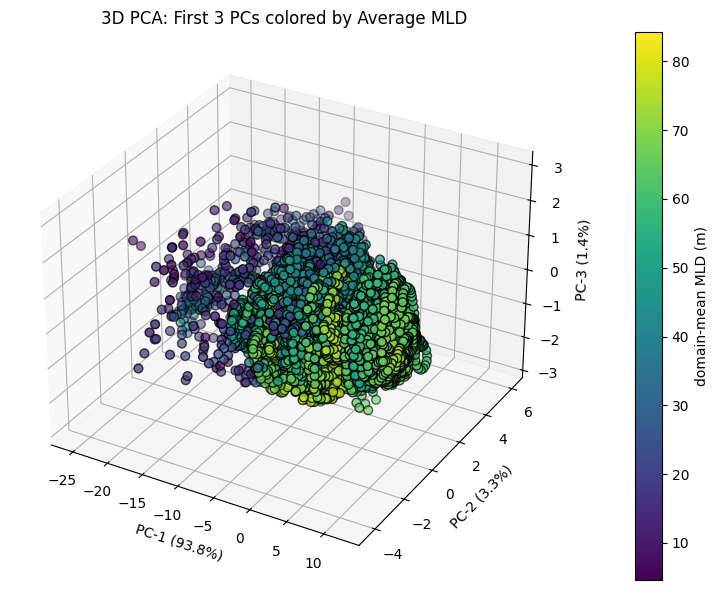

In [148]:
from mpl_toolkits.mplot3d import Axes3D

X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=3)
scores = pca.fit_transform(X_std)
expl_var = pca.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    scores[:, 0], scores[:, 1], scores[:, 2],
    c=mld_mean, cmap="viridis", edgecolor="k", s=40
)
ax.set_xlabel(f"PC-1 ({expl_var[0]:.1f}%)")
ax.set_ylabel(f"PC-2 ({expl_var[1]:.1f}%)")
ax.set_zlabel(f"PC-3 ({expl_var[2]:.1f}%)")
cb = plt.colorbar(sc, ax=ax, pad=0.1)
cb.set_label("domain-mean MLD (m)")
ax.set_title("3D PCA: First 3 PCs colored by Average MLD")
plt.tight_layout()
plt.show()

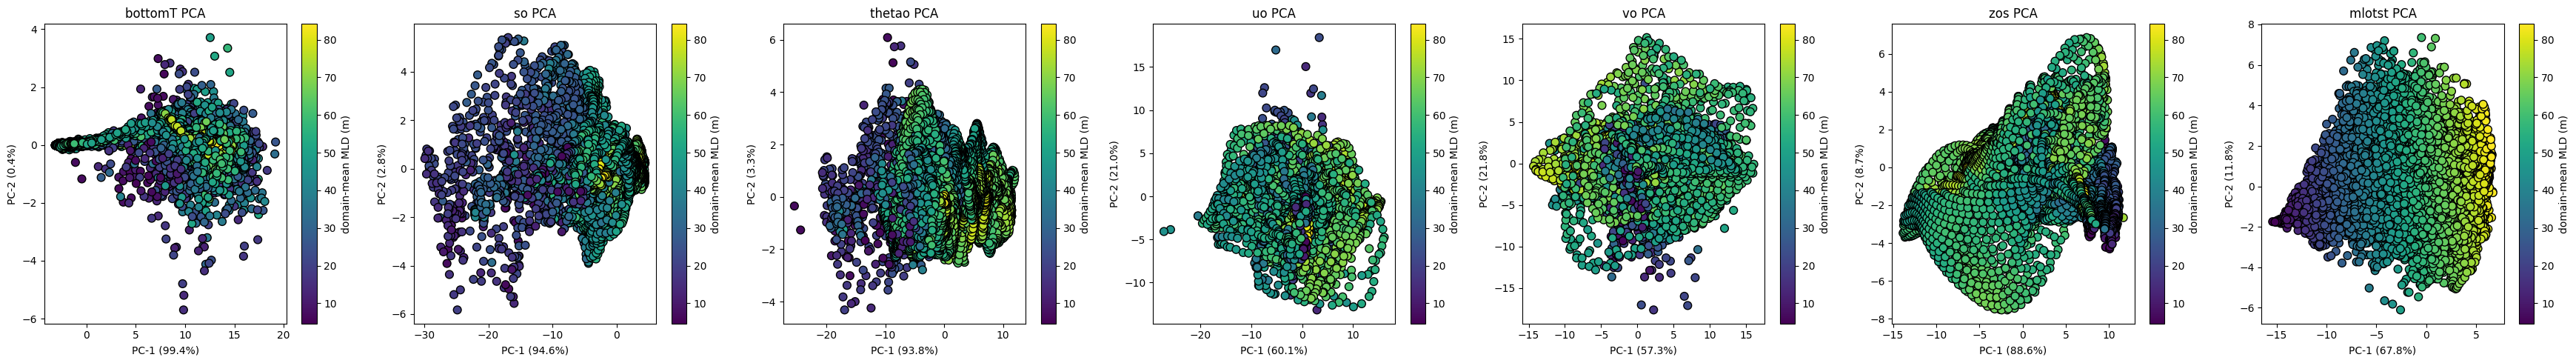

In [151]:
fig, ax = plt.subplots(1, len(ds_nona.data_vars), figsize=(5*len(ds_nona.data_vars), 5))
for i, var in enumerate(ds_nona.data_vars):
    X = ds_nona[var]
    X_std = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_std)
    ax[i].scatter(
        scores[:, 0], scores[:, 1],
        c=mld_mean, cmap="viridis", edgecolor="k", s=60
    )
    ax[i].set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax[i].set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    cb = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cb.set_label("domain-mean MLD (m)")
    ax[i].set_title(f"{var} PCA")
plt.tight_layout()
plt.show()


/tmp/ipykernel_167025/1797273216.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 3500x400 with 8 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(sc, ax=ax[i])
/tmp/ipykernel_167025/1797273216.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 3500x400 with 9 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(sc, ax=ax[i])
/tmp/ipykernel_167025/1797273216.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 3500x400 with 10 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(sc, ax=ax[i])
/tmp/ipykernel_167025/1797273216.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 3500x400 with 11 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(sc, ax=ax[i])
/tmp/ipykernel_167025/1797273216.py:14: UserWarning: Adding colorbar t

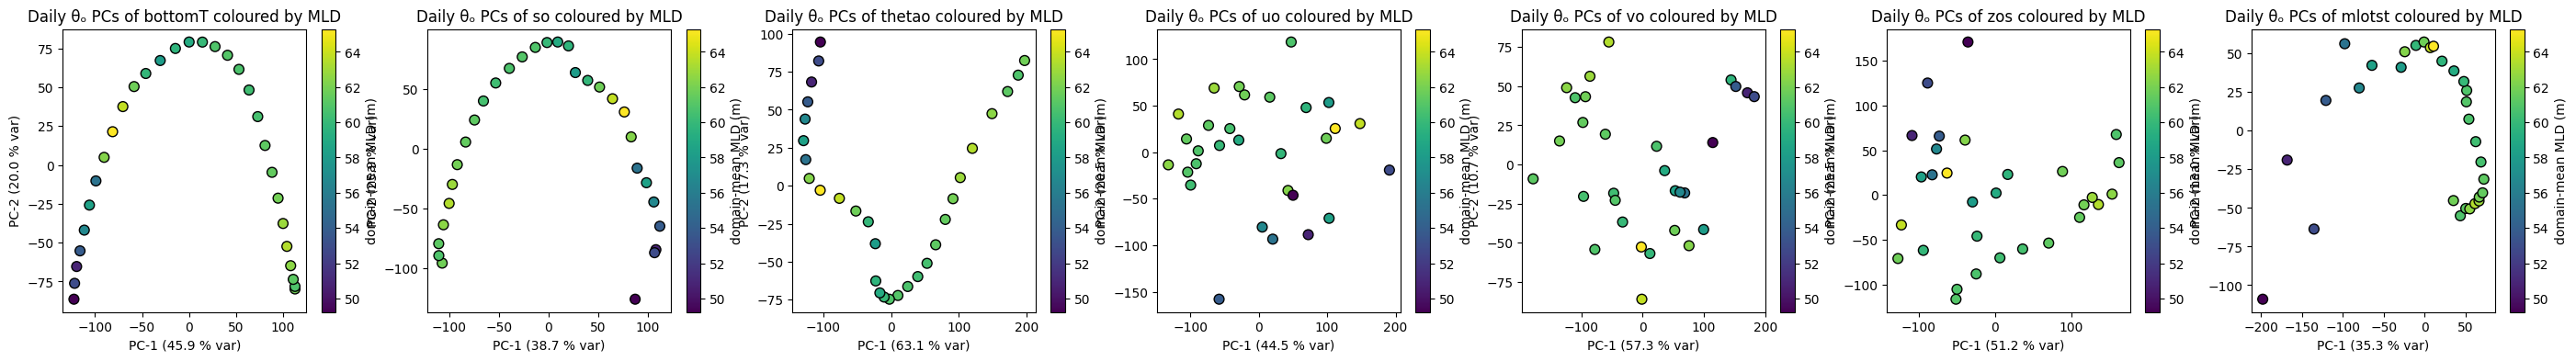

In [ ]:
fig, ax = plt.subplots(1, len(ds.data_vars), figsize=(5*len(ds.data_vars), 4))
for i, var in enumerate(ds.data_vars):
    X = ds[var].stack(spatial=['latitude', 'longitude']).dropna('spatial').squeeze()
    X_std = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_std)
    ax[i].scatter(
    scores[:,0], scores[:,1],
    c=mld_mean, cmap="viridis",
    edgecolor="k", s=60,
    )
    ax[i].set_xlabel("PC-1 ({:.1f} % var)".format(pca.explained_variance_ratio_[0]*100))
    ax[i].set_ylabel("PC-2 ({:.1f} % var)".format(pca.explained_variance_ratio_[1]*100))
    cb = plt.colorbar(sc, ax=ax[i])
    cb.set_label("domain-mean MLD (m)")
    ax[i].set_title(f"Daily θₒ PCs of {var} coloured by Average MLD")